# 03 · Implementação física (OpenLane 2 · SKY130)

RTL → síntese (Yosys) → floorplan → posicionamento → árvore de clock → roteamento
→ análise de timing em 9 corners → DRC, LVS e antena → **GDSII**.

Alvo: `rv32_core` (o núcleo). As memórias de 4 MB / 8 kB do guia dependem da
macro física oficial (SPEC_GAPS SG-02) e não são sintetizadas em flip-flops.

Três rodadas:
- **baseline** — 40 ns (25 MHz), primeira implementação completa;
- **opt30** — 30 ns (33,3 MHz), com reparo de slew/capacitância depois do roteamento global;
- **final** — 30 ns sem a inserção heurística de diodos, que colocava 16.570 diodos
  depois do reparo e era a causa das violações de slew no corner lento (ADR-016).

> Cada rodada leva ~50 min e baixa o PDK SKY130 na primeira vez. Mude
> `RODAR_OPENLANE` para `True` para refazer.

In [1]:
import sys, json
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))          # notebooks/_common.py
from _common import ROOT, run, py, summary, style, SERIES
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import SVG, Image, Markdown, display
print("projeto:", ROOT.name)
RODAR_OPENLANE = False

projeto: ChampionCHIP (Terminar)


In [2]:
if RODAR_OPENLANE:
    run("bash scripts/run_openlane.sh openlane/config/config.json baseline", tail=15)
    run("bash scripts/run_openlane.sh openlane/config/config_opt30.json opt30", tail=15)
    run("bash scripts/run_openlane.sh openlane/config/config_final.json final", tail=15)
print((ROOT / "openlane/config/config_final.json").read_text())

{
  "DESIGN_NAME": "rv32_core",
  "VERILOG_FILES": [
    "dir::../../rtl/core/regfile.sv",
    "dir::../../rtl/core/alu.sv",
    "dir::../../rtl/core/imm_gen.sv",
    "dir::../../rtl/core/branch_cmp.sv",
    "dir::../../rtl/core/mult_unit.sv",
    "dir::../../rtl/core/crc_unit.sv",
    "dir::../../rtl/core/lsu.sv",
    "dir::../../rtl/core/control_unit.sv",
    "dir::../../rtl/core/rv32_core.sv"
  ],
  "VERILOG_INCLUDE_DIRS": [
    "dir::../../rtl/core"
  ],
  "CLOCK_PORT": "clk_i",
  "CLOCK_NET": "clk_i",
  "CLOCK_PERIOD": 30,
  "FP_SIZING": "relative",
  "FP_CORE_UTIL": 35,
  "PL_TARGET_DENSITY_PCT": 45,
  "PDK": "sky130A",
  "STD_CELL_LIBRARY": "sky130_fd_sc_hd",
  "SYNTH_STRATEGY": "AREA 0",
  "RUN_HEURISTIC_DIODE_INSERTION": false,
  "RUN_ANTENNA_REPAIR": true,
  "RUN_POST_GRT_DESIGN_REPAIR": true,
  "RUN_POST_GRT_RESIZER_TIMING": true,
  "GRT_ANTENNA_ITERS": 10,
  "GRT_ANTENNA_MARGIN": 30,
  "DIODE_ON_PORTS": "both",
  "RSZ_CORNERS": [
    "nom_tt_025C_1v80", "min_tt_025C_1v80", 

## Métricas das rodadas

In [3]:
S = summary()
cols = ["label", "clock_period_ns", "clock_mhz", "setup_worst_slack_ns", "fmax_mhz_worst_corner", "hold_worst_slack_ns",
        "drc_klayout", "drc_magic", "lvs_errors", "antenna_violations", "max_slew_violations", "max_cap_violations",
        "instances", "stdcell_area_um2", "die_area_um2", "utilization", "power_total_w"]
pd.DataFrame(S["physical"])[cols].set_index("label").T

reports/summary.json: ISA 44/47, 14 suites, 13 mutantes, 3 runs fisicos



label,baseline,opt30,final
clock_period_ns,40.000000,30.000000,30.000000
clock_mhz,25.000000,33.300000,33.300000
setup_worst_slack_ns,11.568808,1.144826,2.641659
fmax_mhz_worst_corner,35.200000,34.700000,36.600000
hold_worst_slack_ns,0.281533,0.283162,0.281140
drc_klayout,0.000000,0.000000,0.000000
drc_magic,0.000000,0.000000,0.000000
lvs_errors,0.000000,0.000000,0.000000
antenna_violations,2.000000,2.000000,19.000000
max_slew_violations,7486.000000,7620.000000,3139.000000


## Folga de setup por corner

Folga positiva = o sinal chega antes da borda do clock no caminho mais lento.
O corner `ss` (lento, 100 °C, 1,60 V) é sempre o pior.

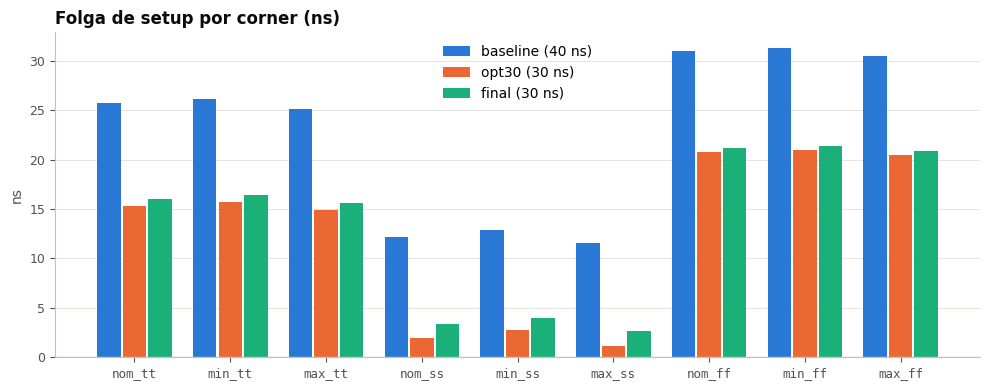

In [4]:
runs = S["physical"]
corners = list(runs[0]["setup_ws_by_corner"])
fig, ax = plt.subplots(figsize=(10, 4))
w = 0.8 / len(runs)
for i, r in enumerate(runs):
    xs = [k + i * w for k in range(len(corners))]
    ax.bar(xs, [r["setup_ws_by_corner"][c] for c in corners], width=w * 0.92, color=SERIES[i],
           label=f"{r['label']} ({r['clock_period_ns']:.0f} ns)")
ax.set_xticks([k + w * (len(runs) - 1) / 2 for k in range(len(corners))])
ax.set_xticklabels([c.replace("_025C_1v80", "").replace("_100C_1v60", "").replace("_n40C_1v95", "") for c in corners],
                   family="monospace", fontsize=9)
style(ax, "Folga de setup por corner (ns)", ylabel="ns")
ax.axhline(0, color="#c3c2b7", linewidth=1); ax.legend(frameon=False); ax.grid(axis="x", visible=False)
plt.tight_layout(); plt.show()

## Layout final (GDSII)

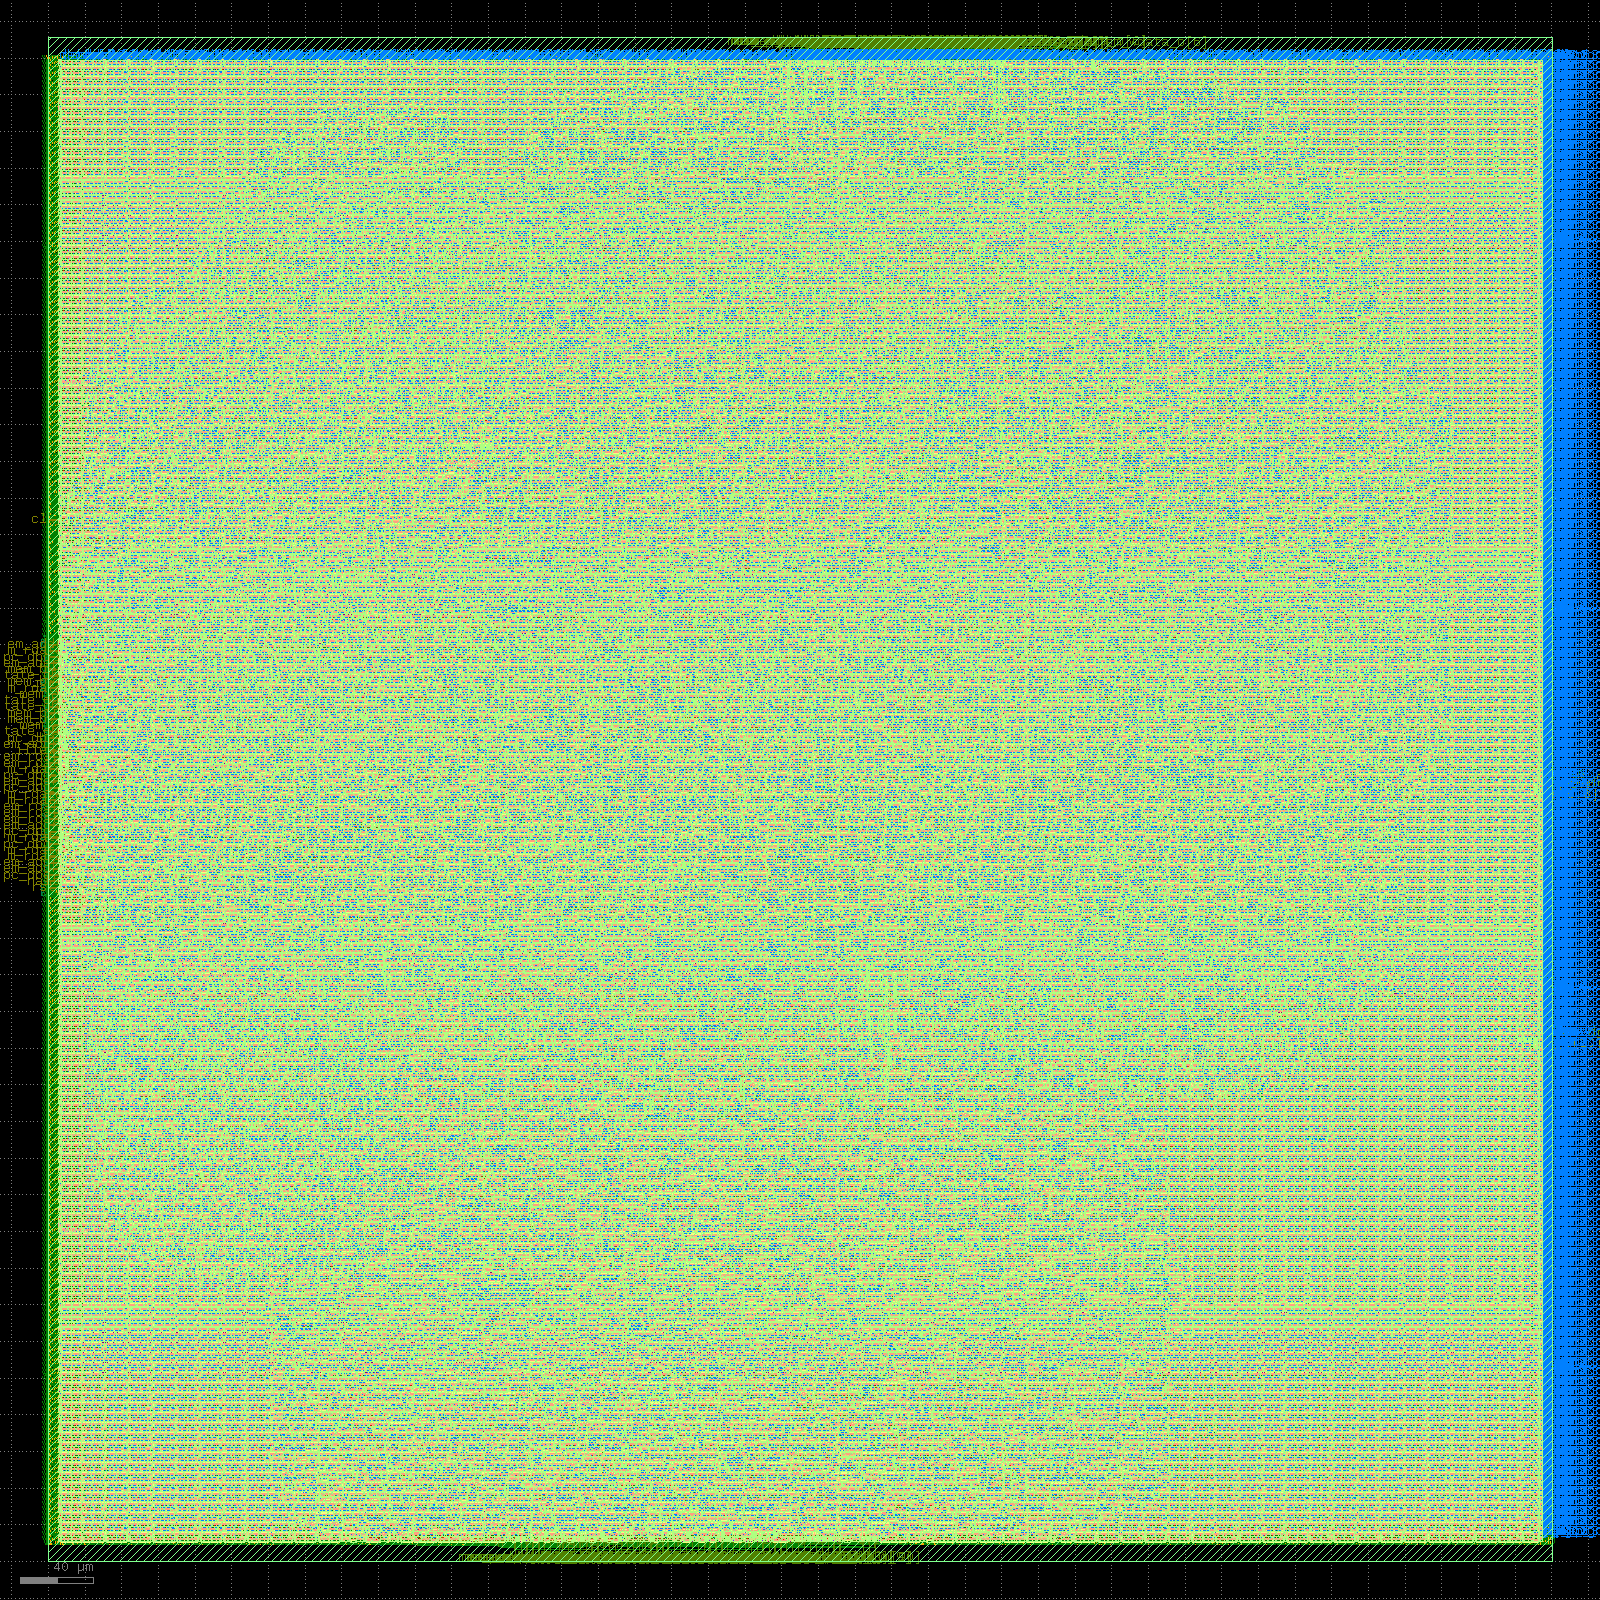

In [5]:
display(Image(filename=str(ROOT / "docs/evidence/openlane/run_final/rv32_core_layout.png"), width=620))

## Gate-level: a netlist pós-layout é equivalente?

A netlist final gerada pelo OpenLane (~31 mil células `sky130_fd_sc_hd`) substitui
o RTL dentro do mesmo SoC e roda o firmware e os programas aleatórios. As netlists
baseline e opt30 passaram no mesmo teste (`docs/evidence/logs/gls_*.log`).

In [6]:
run("bash scripts/run_gls.sh docs/evidence/openlane/run_final/rv32_core.nl.v", tail=8)
pd.read_csv(ROOT / "reports/gls_summary.csv")

netlist: docs/evidence/openlane/run_final/rv32_core.nl.v (5.0M)
==== GL 1. firmware de smoke-test sobre a netlist ====
PASS  gl/firmware
==== GL 2. diferencial randomizado sobre a netlist (10 programas) ====
PASS  gl/random (10/10 programas identicos ao modelo de referencia)
==== GL RESULTADO: NETLIST EQUIVALENTE AO MODELO ====
[exit code 0]


,teste,status
0,firmware,PASS
1,random 10 programas,PASS
